## POLYNOMIAL REGRESSION

In [ ]:
Polynomial linear regression steps

1)Read CSV file
2)Check Null Value
3)Define X & y
4)Split data Into train and test
5)Transform Features to Polynomial Space
6)Train the Model (Fitting)
8) Prediction and Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 1)
df = pd.read_csv('Ice_cream selling data.csv')
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


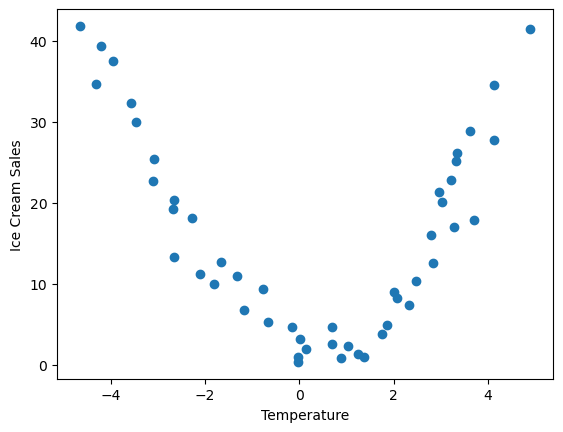

In [2]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])
plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.show()

In [3]:
# 2)
df.isna().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

In [4]:
# 3)
y = df['Ice Cream Sales (units)']
X = df.drop(columns='Ice Cream Sales (units)')

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49, 1)
y shape: (49,)


In [5]:
# 4)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)

Training data size: (39, 1)
Testing data size: (10, 1)
Training data size: (39,)
Testing data size: (10,)


In [23]:
# 5)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
print("X_train_poly:", X_train_poly)

X_train_poly: [[ 1.00000000e+00 -2.11186969e+00  4.45999359e+00 -9.41892528e+00]
 [ 1.00000000e+00 -3.57855372e+00  1.28060467e+01 -4.58271260e+01]
 [ 1.00000000e+00  2.31859124e+00  5.37586534e+00  1.24644343e+01]
 [ 1.00000000e+00 -2.67246083e+00  7.14204687e+00 -1.90868405e+01]
 [ 1.00000000e+00 -3.94966109e+00  1.55998227e+01 -6.16140128e+01]
 [ 1.00000000e+00 -3.10844012e+00  9.66239999e+00 -3.00349918e+01]
 [ 1.00000000e+00  3.21136614e+00  1.03128725e+01  3.31184096e+01]
 [ 1.00000000e+00  3.27004407e+00  1.06931882e+01  3.49671967e+01]
 [ 1.00000000e+00  4.13086796e+00  1.70640701e+01  7.04894205e+01]
 [ 1.00000000e+00 -1.32637898e+00  1.75928121e+00 -2.33347362e+00]
 [ 1.00000000e+00 -2.65228679e+00  7.03462523e+00 -1.86578436e+01]
 [ 1.00000000e+00 -1.17312327e+00  1.37621820e+00 -1.61447359e+00]
 [ 1.00000000e+00  6.88780908e-01  4.74419139e-01  3.26770845e-01]
 [ 1.00000000e+00  2.07510060e+00  4.30604249e+00  8.93547133e+00]
 [ 1.00000000e+00  1.74000001e+00  3.02760004e+0

In [24]:
# 6)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
m = lr.coef_
print("Coefficients (m):", m)

c = lr.intercept_
print("Intercept (c):", c)

Coefficients (m): [ 0.         -1.39956426  1.87501919  0.05451597]
Intercept (c): 2.840530985282797


##### example

In [25]:

x1 = poly.transform([[25]])
x1

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[1.0000e+00, 2.5000e+01, 6.2500e+02, 1.5625e+04]])

In [31]:
# MSE
x_test_poly=poly.transform(X_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
y_test_pred = lr.predict(X_test_poly)
mse = mean_squared_error(y_test, y_test_pred)
print("mse:", mse)
mae = mean_absolute_error(y_test, y_test_pred)
print("mae:", mae)
r2 = r2_score(y_test, y_test_pred)
print("r2:", r2)

mse: 15.120009451229496
mae: 3.22812112977689
r2: 0.8405107685716914


# CH-5-Classification Algorithm

### KNN ALGORITHM(K Nearest Neighbour)

### MODAL ACCURACY

Accuracy=TP+TN/TP+TN+FP+FN

### ERROR RATE

1)Error Rate=FP+FN/TP+TN+FP+FN
2)Error Rate=1-Accuracy

In [ ]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

### SENSITIVITY

Semsitivity=TP/TP+FN

### SPECIFICITY

Specificity=TN/TN+FP

In [ ]:
KNN

1)Read CSV file
2)Check Null Value
3)Define X & y
4)Split data Into train and test
5)Train KNN Model
6)Prediction
7)

In [32]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [33]:
# 2)
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [35]:
# 3)
y = df['Outcome']
X = df.drop(columns='Outcome')

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [36]:
# 4)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)

Training data size: (614, 8)
Testing data size: (154, 8)
Training data size: (614,)
Testing data size: (154,)


In [38]:
# 5)
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=25)
model=knn.fit(X_train, y_train)
model

,n_neighbors,25
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
# 6)
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [41]:
# 7)
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))

[[83 16]
 [28 27]]
Accuracy: 0.7142857142857143
